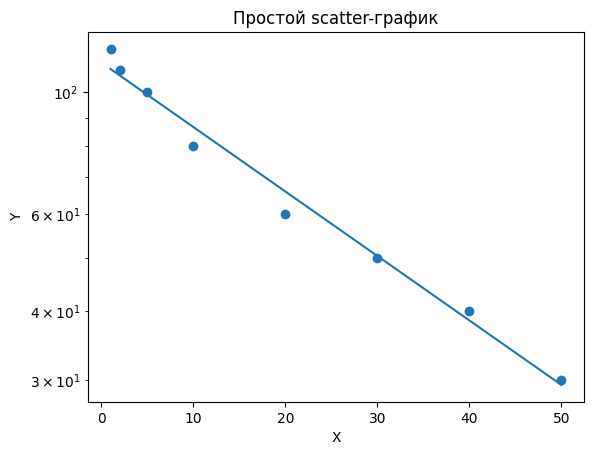

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# Данные
bs = np.array([120, 110, 100, 80, 60, 50, 40, 30])
uc = np.array([1, 2, 5, 10, 20, 30, 40, 50])

log_bs = np.log10(bs)
k, b = np.polyfit(uc, log_bs, 1)

uc_line = np.linspace(uc.min(), uc.max(), 100)
bs_line = 10 ** (k * uc_line + b)

# Построение scatter
plt.scatter(uc, bs)
plt.plot(uc_line, bs_line)
plt.xlabel("X")
plt.ylabel("Y")
plt.yscale('log')
plt.title("Простой scatter-график")

# Отображение
plt.show()

Модель с интерсептом: bs = a + C*log(uc+1)
  a = 139.878, C = -26.810, R^2 = 0.9930

Модель без интерсепта: bs = C*log(uc+1)
  C = 19.324, R^2 = -2.5545


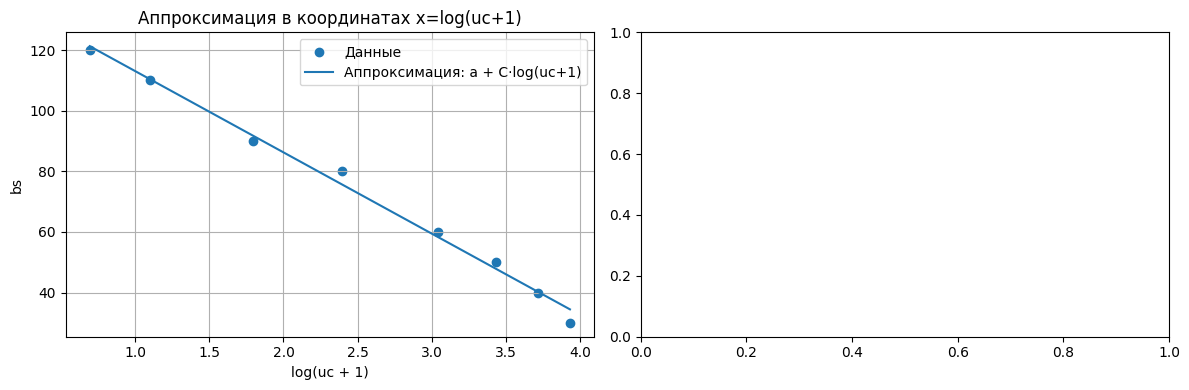

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# данные
bs = np.array([120, 110, 90, 80, 60, 50, 40, 30], dtype=float)
uc = np.array([1, 2, 5, 10, 20, 30, 40, 50], dtype=float)

# x = log(uc + 1)
x = np.log(uc + 1).reshape(-1, 1)
y = bs

# 1) Модель с интерсептом: bs = a + C*log(uc+1)
m1 = LinearRegression(fit_intercept=True)
m1.fit(x, y)
C1 = m1.coef_[0]
a1 = m1.intercept_
y1 = m1.predict(x)
R2_1 = r2_score(y, y1)

# 2) Строго по вашей формуле (через 0): bs = C*log(uc+1)
m0 = LinearRegression(fit_intercept=False)
m0.fit(x, y)
C0 = m0.coef_[0]
y0 = m0.predict(x)
R2_0 = r2_score(y, y0)

print("Модель с интерсептом: bs = a + C*log(uc+1)")
print(f"  a = {a1:.3f}, C = {C1:.3f}, R^2 = {R2_1:.4f}")
print()
print("Модель без интерсепта: bs = C*log(uc+1)")
print(f"  C = {C0:.3f}, R^2 = {R2_0:.4f}")

# --- Графики ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# (A) bs vs log(uc+1)
axes[0].scatter(x, y, label="Данные")
axes[0].plot(x, y1, label="Аппроксимация: a + C·log(uc+1)")
axes[0].set_xlabel("log(uc + 1)")
axes[0].set_ylabel("bs")
axes[0].set_title("Аппроксимация в координатах x=log(uc+1)")
axes[0].grid(True)
axes[0].legend()

# (B) Остатки для модели с интерсептом
# res1 = y - y1
# axes[1].axhline(0, linewidth=1)
# axes[1].scatter(x, res1)
# axes[1].set_xlabel("log(uc + 1)")
# axes[1].set_ylabel("остаток (bs - модель)")
# axes[1].set_title("Остатки для bs = a + C·log(uc+1)")
# axes[1].grid(True)

plt.tight_layout()
plt.show()


Модель: bs = a + C*log(uc + 1)
a = 139.878
C = -26.810
R^2 = 0.9930


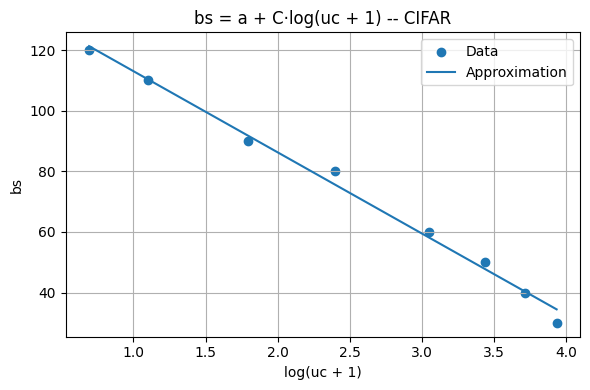

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# данные
bs = np.array([120, 110, 90, 80, 60, 50, 40, 30], dtype=float)
uc = np.array([1, 2, 5, 10, 20, 30, 40, 50], dtype=float)

# bs = np.array([120, 100, 90, 80, 60, 50, 40, 30], dtype=float)
# uc = np.array([1, 2, 5, 10, 20, 30, 40, 50], dtype=float)

# x = log(uc + 1)
x = np.log(uc + 1).reshape(-1, 1)
y = bs

# модель с интерсептом: bs = a + C*log(uc+1)
model = LinearRegression(fit_intercept=True)
model.fit(x, y)

a = model.intercept_
C = model.coef_[0]
y_pred = model.predict(x)
R2 = r2_score(y, y_pred)

print("Модель: bs = a + C*log(uc + 1)")
print(f"a = {a:.3f}")
print(f"C = {C:.3f}")
print(f"R^2 = {R2:.4f}")

# график
plt.figure(figsize=(6, 4))
plt.scatter(x, y, label="Data")
plt.plot(x, y_pred, label="Approximation")
plt.xlabel("log(uc + 1)")
plt.ylabel("bs")
plt.title("bs = a + C·log(uc + 1) -- CIFAR")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(
    "/Users/alex/Downloads/log_CIFAR.pdf",
    format="pdf",
    bbox_inches="tight"
)
plt.show()


Модель: bs = a + C*log(uc + 1)
a = 139.318
C = -27.582
R^2 = 0.9919


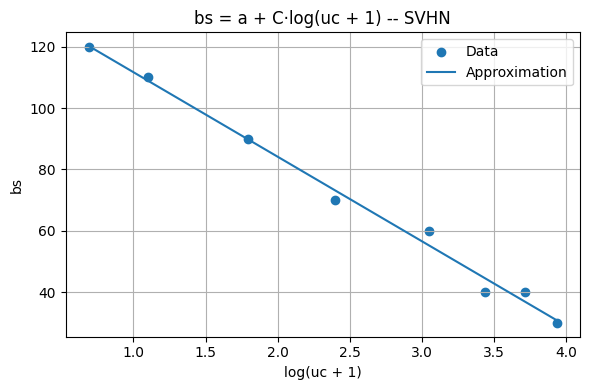

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# данные
bs = np.array([120, 110, 90, 70, 60, 40, 40, 30], dtype=float)
uc = np.array([1, 2, 5, 10, 20, 30, 40, 50], dtype=float)

# x = log(uc + 1)
x = np.log(uc + 1).reshape(-1, 1)
y = bs

# модель с интерсептом: bs = a + C*log(uc+1)
model = LinearRegression(fit_intercept=True)
model.fit(x, y)

a = model.intercept_
C = model.coef_[0]
y_pred = model.predict(x)
R2 = r2_score(y, y_pred)

print("Модель: bs = a + C*log(uc + 1)")
print(f"a = {a:.3f}")
print(f"C = {C:.3f}")
print(f"R^2 = {R2:.4f}")

# график
plt.figure(figsize=(6, 4))
plt.scatter(x, y, label="Data")
plt.plot(x, y_pred, label="Approximation")
plt.xlabel("log(uc + 1)")
plt.ylabel("bs")
plt.title("bs = a + C·log(uc + 1) -- SVHN")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(
    "/Users/alex/Downloads/log_SVHN.pdf",
    format="pdf",
    bbox_inches="tight"
)
plt.show()